In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df = pd.read_csv("house_price_dataset(1).csv")
print(df.info())
print(df)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   HouseID                  1000 non-null   int64  
 1   Area_sqft                1000 non-null   int64  
 2   Bedrooms                 1000 non-null   int64  
 3   Bathrooms                1000 non-null   int64  
 4   Floors                   1000 non-null   int64  
 5   YearBuilt                1000 non-null   int64  
 6   HouseAge                 1000 non-null   int64  
 7   Location                 1000 non-null   str    
 8   Garage                   1000 non-null   str    
 9   HasGarden                1000 non-null   str    
 10  DistanceToCityCenter_km  1000 non-null   float64
 11  SchoolRating             1000 non-null   int64  
 12  CrimeRate                1000 non-null   float64
 13  Price                    1000 non-null   int64  
dtypes: float64(2), int64(9), str(3)
memo

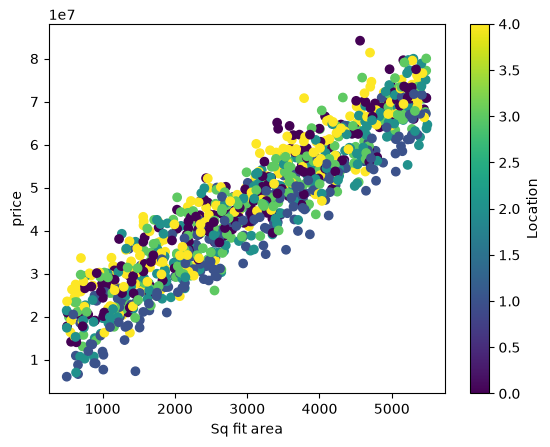

In [99]:
plt.scatter(df['Area_sqft'], df['Price'], c=df['Location'].astype('category').cat.codes, cmap='viridis')
plt.xlabel('Sq fit area')
plt.ylabel('price')
plt.colorbar(label = 'Location')
plt.show()

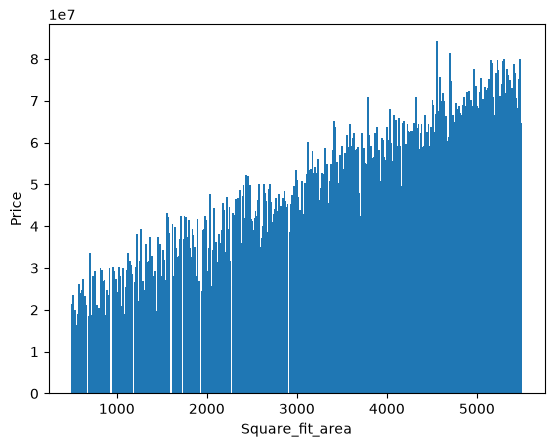

In [100]:
plt.Figure(figsize=(15,8))
plt.bar(df['Area_sqft'],df['Price'], width=20)
plt.xlabel('Square_fit_area')
plt.ylabel('Price')
plt.show()

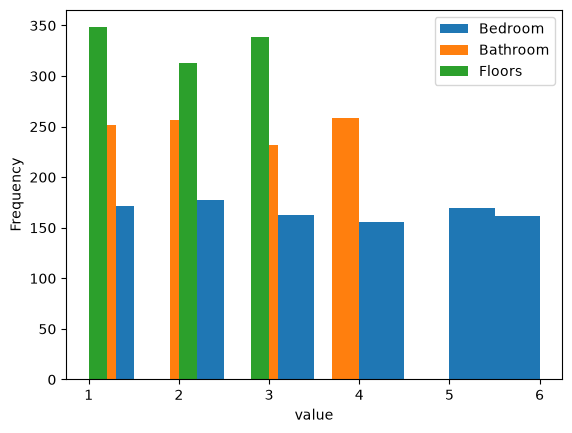

In [101]:
plt.hist(df['Bedrooms'],label='Bedroom')
plt.hist(df['Bathrooms'], label='Bathroom')
plt.hist(df['Floors'], label='Floors')
plt.xlabel('value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [102]:
df = df.iloc[:,1:]
print(df)

     Area_sqft  Bedrooms  Bathrooms  Floors  YearBuilt  HouseAge    Location  \
0         1360         4          3       1       2000        26      Uptown   
1         4272         1          1       1       1972        54      Suburb   
2         3592         2          4       1       1977        49      Uptown   
3          966         3          2       2       1996        30       Rural   
4         4926         6          2       1       1972        54  Waterfront   
..         ...       ...        ...     ...        ...       ...         ...   
995       1832         2          2       2       2018         8  Waterfront   
996        701         5          3       2       2019         7  Waterfront   
997       4007         1          1       3       1997        29  Waterfront   
998       4712         3          1       1       2017         9       Rural   
999       1074         5          4       3       1999        27      Uptown   

    Garage HasGarden  DistanceToCityCen

In [103]:
df = df[['Area_sqft',
        'Bedrooms',
        'Bathrooms',
        'Floors',
        'HouseAge',
        'HasGarden',
        'Location',
        'Price']]
print(df)

     Area_sqft  Bedrooms  Bathrooms  Floors  HouseAge HasGarden    Location  \
0         1360         4          3       1        26        No      Uptown   
1         4272         1          1       1        54        No      Suburb   
2         3592         2          4       1        49       Yes      Uptown   
3          966         3          2       2        30       Yes       Rural   
4         4926         6          2       1        54        No  Waterfront   
..         ...       ...        ...     ...       ...       ...         ...   
995       1832         2          2       2         8        No  Waterfront   
996        701         5          3       2         7        No  Waterfront   
997       4007         1          1       3        29        No  Waterfront   
998       4712         3          1       1         9       Yes       Rural   
999       1074         5          4       3        27        No      Uptown   

        Price  
0    31616000  
1    52712000  
2  

## Describe the dataset through Heatmap

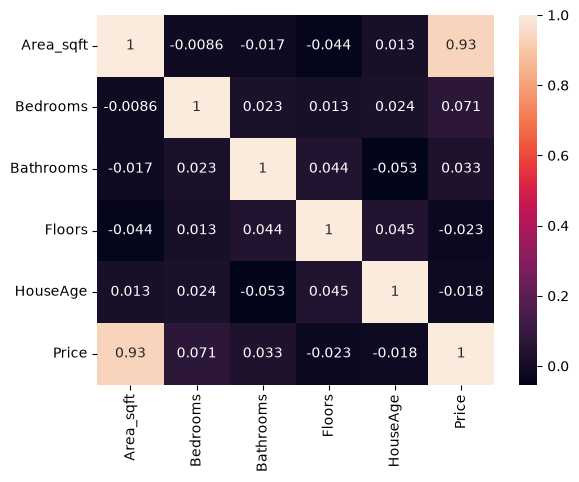

In [104]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [105]:
x = df[['Area_sqft',
        'Bedrooms',
        'Bathrooms',
        'Floors',
        'HouseAge',
        'HasGarden',
        'Location',]]

y = df['Price']
print(x)
print(y)

     Area_sqft  Bedrooms  Bathrooms  Floors  HouseAge HasGarden    Location
0         1360         4          3       1        26        No      Uptown
1         4272         1          1       1        54        No      Suburb
2         3592         2          4       1        49       Yes      Uptown
3          966         3          2       2        30       Yes       Rural
4         4926         6          2       1        54        No  Waterfront
..         ...       ...        ...     ...       ...       ...         ...
995       1832         2          2       2         8        No  Waterfront
996        701         5          3       2         7        No  Waterfront
997       4007         1          1       3        29        No  Waterfront
998       4712         3          1       1         9       Yes       Rural
999       1074         5          4       3        27        No      Uptown

[1000 rows x 7 columns]
0      31616000
1      52712000
2      54041000
3      24901000

In [106]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
x["HasGarden"] = LabelEncoder().fit_transform(df['HasGarden'])

#OneHotEncoding the location feature
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['Location']])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Location'])
)

x = pd.concat([x.drop('Location', axis=1), encoded_df], axis=1)
x[encoder.get_feature_names_out(['Location'])] = encoded
# x['Location'] = OneHotEncoder(sparse_output=False).fit_transform(df[['Location']])
print(x)


     Area_sqft  Bedrooms  Bathrooms  Floors  HouseAge  HasGarden  \
0         1360         4          3       1        26          0   
1         4272         1          1       1        54          0   
2         3592         2          4       1        49          1   
3          966         3          2       2        30          1   
4         4926         6          2       1        54          0   
..         ...       ...        ...     ...       ...        ...   
995       1832         2          2       2         8          0   
996        701         5          3       2         7          0   
997       4007         1          1       3        29          0   
998       4712         3          1       1         9          1   
999       1074         5          4       3        27          0   

     Location_Downtown  Location_Rural  Location_Suburb  Location_Uptown  \
0                  0.0             0.0              0.0              1.0   
1                  0.0         

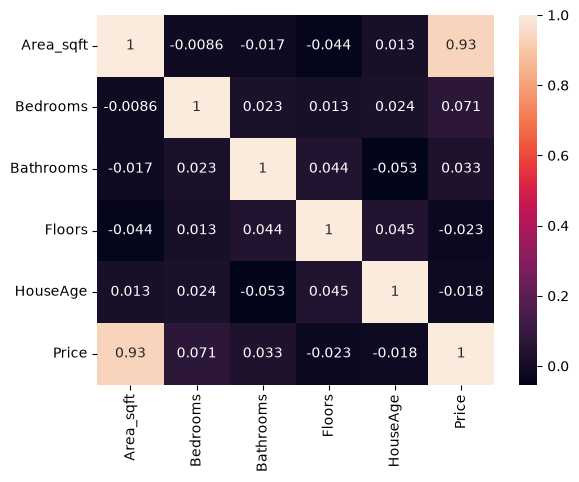

In [107]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

## Train Test and Split

In [108]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.1, random_state= 50)

In [109]:
print(x_train,y_train)

     Area_sqft  Bedrooms  Bathrooms  Floors  HouseAge  HasGarden  \
528       1865         3          2       3        44          0   
10        1269         1          4       2        58          0   
321       4841         2          1       2        17          1   
657        749         4          2       2        38          0   
368       4175         6          2       1        38          0   
..         ...       ...        ...     ...       ...        ...   
289       3920         5          1       1        61          0   
109       1370         3          2       2        35          1   
907       5416         5          4       2        48          0   
480       4452         6          3       3        64          0   
688       4844         4          1       1        44          0   

     Location_Downtown  Location_Rural  Location_Suburb  Location_Uptown  \
528                0.0             0.0              0.0              0.0   
10                 1.0         

In [110]:
print(x_test,y_test)

     Area_sqft  Bedrooms  Bathrooms  Floors  HouseAge  HasGarden  \
316       3037         5          1       3        28          0   
459        912         1          3       3        40          1   
854       1842         5          1       2        19          1   
11        2891         3          2       3        29          1   
978       3867         1          1       1        42          1   
..         ...       ...        ...     ...       ...        ...   
745       1776         3          3       3        34          1   
441       4469         1          4       1        44          0   
991       4521         6          3       3        65          0   
396       3856         2          2       1         9          0   
795       3948         4          3       2        32          1   

     Location_Downtown  Location_Rural  Location_Suburb  Location_Uptown  \
316                0.0             1.0              0.0              0.0   
459                0.0         

In [111]:
from sklearn.preprocessing import StandardScaler

x_train = StandardScaler().fit_transform(x_train)
x_test = StandardScaler().fit_transform(x_test)
print(x_train)
print(x_test)

[[-0.83644347 -0.26344958 -0.43391009 ... -0.48956044 -0.48956044
   1.87686256]
 [-1.25908346 -1.43145267  1.33314459 ... -0.48956044 -0.48956044
  -0.53280406]
 [ 1.27391999 -0.84745113 -1.31743744 ... -0.48956044  2.04264872
  -0.53280406]
 ...
 [ 1.6816683   0.9045535   1.33314459 ... -0.48956044 -0.48956044
  -0.53280406]
 [ 0.99806939  1.48855504  0.44961725 ... -0.48956044 -0.48956044
  -0.53280406]
 [ 1.27604737  0.32055196 -1.31743744 ...  2.04264872 -0.48956044
  -0.53280406]]
[[-0.12102073  0.82789587 -1.43221768 ... -0.51558005 -0.5
  -0.46852129]
 [-1.74353842 -1.45595481  0.40395883 ... -0.51558005  2.
  -0.46852129]
 [-1.03344833  0.82789587 -1.43221768 ...  1.93956303 -0.5
  -0.46852129]
 ...
 [ 1.01206927  1.39885854  0.40395883 ...  1.93956303 -0.5
  -0.46852129]
 [ 0.50431668 -0.88499214 -0.51412942 ... -0.51558005  2.
  -0.46852129]
 [ 0.57456215  0.2569332   0.40395883 ...  1.93956303 -0.5
  -0.46852129]]


## Now Train the model

In [112]:
from sklearn.linear_model import LinearRegression

In [113]:
clf = LinearRegression()

In [114]:
clf.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[15574220.78, 1354730.61, 763587.79,..., -437490.31, 249995. , 1133564.92]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.532e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[34.22,34.07,33.96,...,28.92,27.41, 0. ]"


## Evaluate the model

In [115]:
# prediction
y_pred = clf.predict(x_test)
print(y_pred)

[39424139.25426808 17630375.79846177 28855940.78897996 44557146.05387104
 45812507.71020722 73772603.76694141 32373048.47104364 57290297.94196671
 63672315.87622532 13937881.71866443 30282762.17747607 27389460.75416129
 40256385.04459894 42117416.17975816 49861319.8583058  24886041.63412885
 25861402.73625017 65852270.26132277 65967693.98823725 52576386.56288906
 72045485.85955724 54269302.83390972 43203199.29144382 51343906.30145796
 50222452.80271354 55116571.29794277 21885568.37550707 25590445.43633673
 21694983.58433975 68377489.45914802 52585303.3241969  48737636.85148741
 68476645.73380688 40088078.73277532 37210424.82479373 71231386.96975508
 57671549.53028944 44245368.10779932 44350516.85541493 23226766.93327812
 31820443.88047807 31301297.26342393 33492795.04635644 59386169.32869914
 62176274.98775437 43047660.05843578 24998754.91666131 47987576.69381376
 45521908.72941504 18658152.65271321 35099237.75715454 65620162.673659
 13324684.73450632 57553025.35627679 48376955.1989684

In [116]:
print(y_test)

316    43930000
459    14477000
854    39259000
11     44681000
978    39114000
         ...   
745    27098000
441    59135000
991    50994000
396    46109000
795    61089000
Name: Price, Length: 100, dtype: int64


## Testing value VS Prediction Value

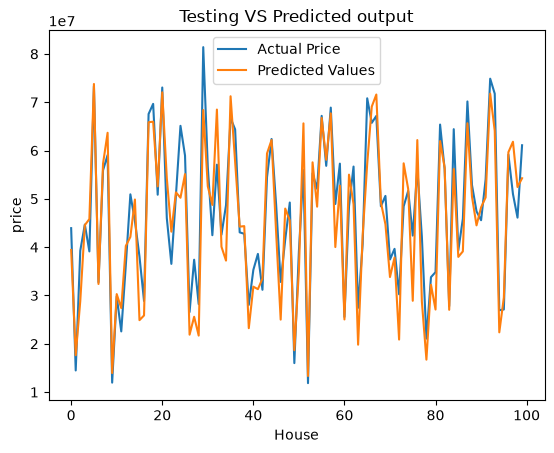

In [122]:
plt.plot(y_test.values, label= 'Actual Price')
plt.plot(y_pred, label = 'Predicted Values')
plt.title('Testing VS Predicted output')
plt.xlabel('House')
plt.ylabel('price')
plt.legend()
plt.show()

In [121]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 4895155.514844307
MSE: 6109449.7783480715
R2 Score: 0.8398343376728122


## Deploy the model

In [118]:
import pickle

pickle.dump(clf,open('HouseModel.pkl','wb'))